In [2]:
#Importing all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
print("All Libraries Imported Successfully!")

All Libraries Imported Successfully!


In [3]:
#Task 1: Data Loading & Exploration

df=pd.read_csv('HR_Attrition.csv')
df_original=df.copy()
df.head(10)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
df.shape


(1470, 35)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [7]:
#Attrition Rate in Percentage
attrition_rate = (
    df['Attrition'].value_counts(normalize=True)[1]
    *100
)

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


C:\Users\PAKSHAL\AppData\Local\Temp\ipykernel_31524\1302133116.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['Attrition'].value_counts(normalize=True)[1]


In [8]:
# Numeric vs Categorical
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include="object").columns

print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))


Numeric Columns: 26
Categorical Columns: 9


In [9]:
#Observation:
#The dataset is imbalanced because the number of employees who stayed is significantly higher than those who left. 
#Therefore, model evaluation should focus on Precision, Recall and ROC-AUC rather than Accuracy alone.

In [10]:
#Task-2: Data Cleaning & Preprocessing

# Missing Values
print(df.isnull().sum())

#Dropping columns because they contain no predictive information.
drop_cols = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df.drop(columns=drop_cols, inplace=True)

# Convert Target Variable
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

# One Hot Encoding
df = pd.get_dummies(df, drop_first=True, dtype=int)

df.head()


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,0,0,0,0,0,1,0,0,1,1
1,49,0,279,8,1,3,61,2,2,2,...,0,0,0,0,1,0,0,1,0,0
2,37,1,1373,2,2,4,92,2,1,3,...,1,0,0,0,0,0,0,0,1,1
3,33,0,1392,3,4,4,56,3,1,3,...,0,0,0,0,1,0,0,1,0,1
4,27,0,591,2,1,1,40,3,1,2,...,1,0,0,0,0,0,0,1,0,0


In [11]:
#Feature and Target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [12]:
#Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

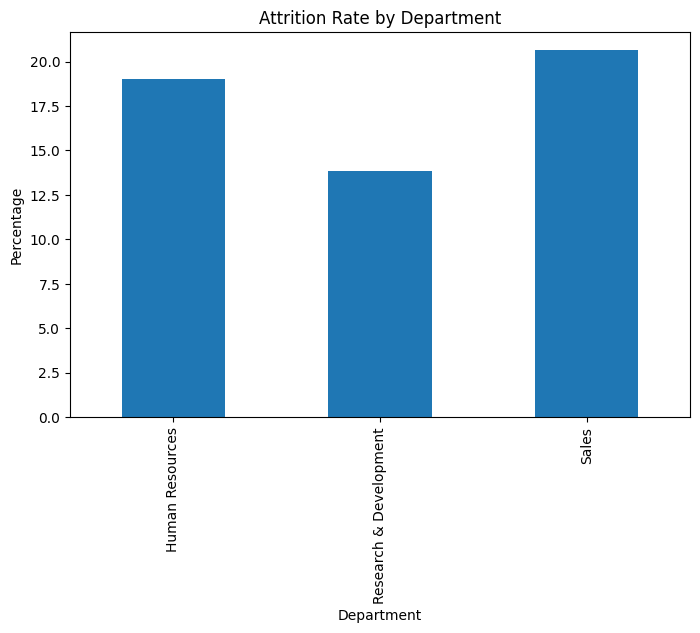

In [13]:
#Task-3: EDA(Exploratory Data Analysis)
#Chart 1: Attrition by Department
plt.figure(figsize=(8,5))

department_attrition = pd.crosstab(
    df_original["Department"],
    df_original["Attrition"],
    normalize="index"
)*100

department_attrition["Yes"].plot(
    kind="bar"
)

plt.title("Attrition Rate by Department")
plt.ylabel("Percentage")
plt.show()


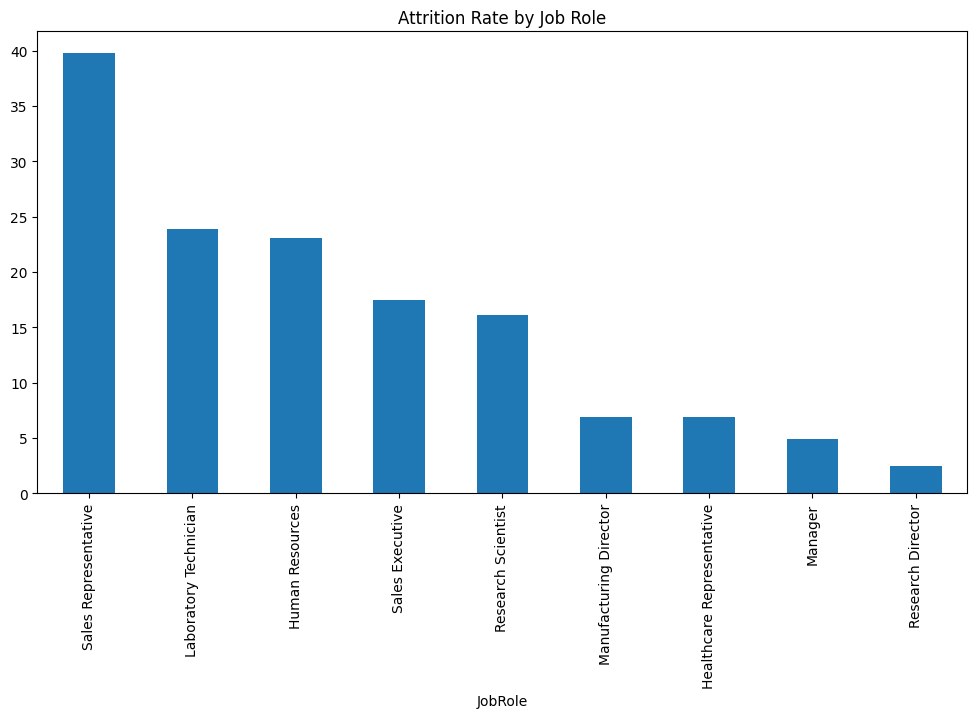

In [14]:
#Chart 2: Attrition by Job Role
plt.figure(figsize=(12,6))

jobrole_attrition = pd.crosstab(
    df_original["JobRole"],
    df_original["Attrition"],
    normalize="index"
)*100

jobrole_attrition["Yes"].sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Attrition Rate by Job Role")
plt.show()

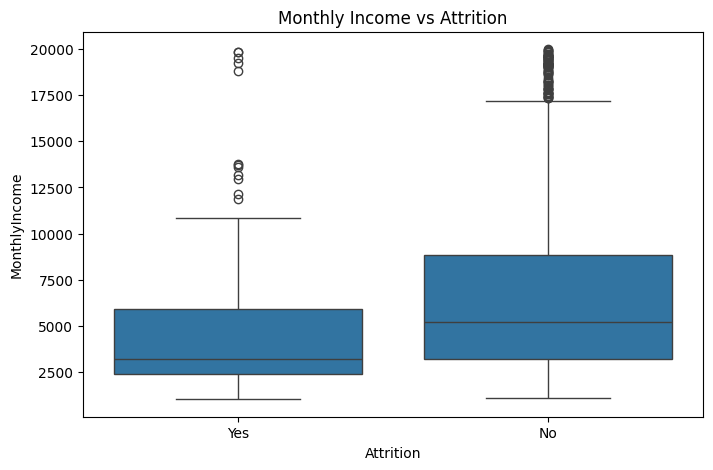

In [15]:
#Chart 3: Monthly Income vs Attrition
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df_original
)

plt.title("Monthly Income vs Attrition")
plt.show()

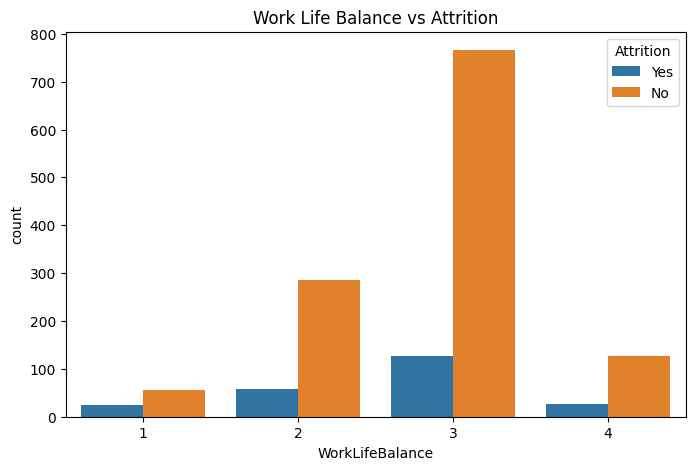

In [16]:
#Chart 4: Work Life Balance
plt.figure(figsize=(8,5))

sns.countplot(
    x="WorkLifeBalance",
    hue="Attrition",
    data=df_original
)

plt.title("Work Life Balance vs Attrition")
plt.show()

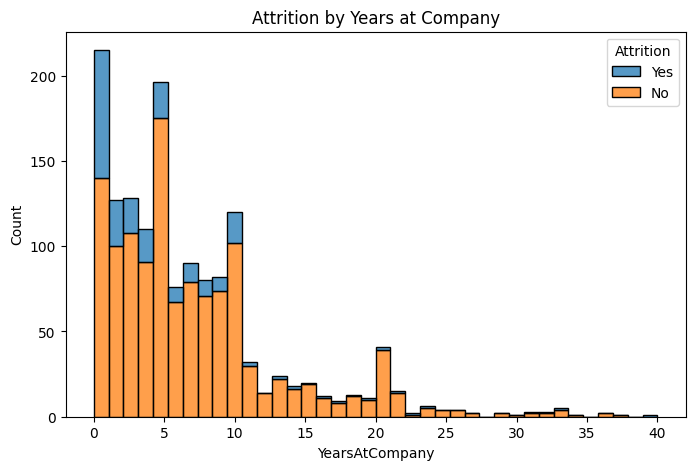

In [17]:
#Chart 5: Years at Company
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_original,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack"
)

plt.title("Attrition by Years at Company")
plt.show()

In [18]:
#1. Which department loses the most employees?
#Answer: Sales Department (≈21% attrition)

#2. Which job roles have the highest exit rate?
#Answer: Sales Representative, (Highest)Laboratory Technician, Human Resources, Sales Executive

#3. Do lower-paid employees leave more?
#Answer: Yes. The box plot shows that employees who left generally have a lower median monthly income than employees who stayed. However, salary is only one contributing factor, as some higher-paid employees also resigned.

#4. Is there a visible pattern with Work-Life Balance?
#Answer:Yes. Employees with poor or average work-life balance (ratings 1 and 2) exhibit higher attrition. Better work-life balance is associated with improved employee retention.

#5. At what point in tenure do employees leave most?
#Answer:The majority of employee exits occur during the first five years of employment. After this period, attrition decreases considerably.

In [19]:
# Business Insights from Exploratory Data Analysis:

#1. The Sales department has the highest employee attrition rate (approximately 21%), followed by Human Resources (around 19%), while Research & Development has the lowest attrition rate (approximately 14%). This indicates that retention efforts should primarily focus on the Sales department.

#2. Sales Representatives experience the highest attrition rate (nearly 40%), making them the most vulnerable employee group. Laboratory Technicians and Human Resources employees also show relatively high turnover compared to other job roles.

#3. Employees who left the company generally earned lower monthly salaries than those who stayed.Although salary influences employee decisions, the overlap in salary ranges suggests that compensation alone is not the only reason employees resign.

#4. Employees with lower Work-Life Balance ratings (particularly ratings of 1 and 2) are more likely to leave the company. Employees reporting better work-life balance tend to have lower attrition, highlighting the importance of employee well-being.

#5. Most employee exits occur within the first five years of employment. Attrition decreases significantly after employees gain longer tenure, suggesting that early-career employees require additional support, mentoring, and career development opportunities to improve retention.

In [20]:
#Task 4 — Model Building & Comparison

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y #Since the dataset is imbalanced, stratify=y ensures that both the training and testing sets maintain the same proportion of employees who stayed and employees who left.
)

print("Training Set Shape :", X_train.shape)
print("Testing Set Shape  :", X_test.shape)

Training Set Shape : (1176, 44)
Testing Set Shape  : (294, 44)


In [21]:
# Logistic Regression Model

lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [22]:
# Random Forest Classifier Model

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [23]:
# Gradient Boosting Classifier Model

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Model Trained Successfully!")

Gradient Boosting Model Trained Successfully!


In [24]:
# Store model performance
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision":[

        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)

    ],

    "Recall":[

        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)

    ],

    "F1 Score":[

        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)

    ],

    "ROC-AUC":[

        roc_auc_score(
            y_test,
            lr_model.predict_proba(X_test)[:,1]
        ),

        roc_auc_score(
            y_test,
            rf_model.predict_proba(X_test)[:,1]
        ),

        roc_auc_score(
            y_test,
            gb_model.predict_proba(X_test)[:,1]
        )

    ]

})

comparison = comparison.round(3)

comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.341,0.617,0.439,0.799
1,Random Forest,0.571,0.085,0.148,0.782
2,Gradient Boosting,0.588,0.213,0.312,0.794


In [25]:
#Task-5: Model Evaluation
# Function to evaluate classification models

def evaluate_model(model_name, model, y_true, y_pred):

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(
        y_true,
        model.predict_proba(X_test)[:,1]
    )

    print("="*60)
    print(model_name)
    print("="*60)

    print(classification_report(y_true, y_pred))

    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1 Score  : {f1:.3f}")
    print(f"ROC-AUC   : {roc_auc:.3f}")

    return precision, recall, f1, roc_auc

In [26]:
lr_precision, lr_recall, lr_f1, lr_auc = evaluate_model(
    "Logistic Regression",
    lr_model,
    y_test,
    lr_pred
)
rf_precision, rf_recall, rf_f1, rf_auc = evaluate_model(
    "Random Forest",
    rf_model,
    y_test,
    rf_pred
)
gb_precision, gb_recall, gb_f1, gb_auc = evaluate_model(
    "Gradient Boosting",
    gb_model,
    y_test,
    gb_pred
)

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

Precision : 0.341
Recall    : 0.617
F1 Score  : 0.439
ROC-AUC   : 0.799
Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

Precision : 0.571
Recall    : 0.085
F1 Score  : 0.148
ROC-AUC   : 0.782
Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.

In [27]:
best_model_name = comparison.loc[
    comparison["ROC-AUC"].idxmax(),
    "Model"
]

print("Best Performing Model:", best_model_name)
best_model = lr_model
best_prediction = lr_pred

print("Best Model : Logistic Regression")

Best Performing Model: Logistic Regression
Best Model : Logistic Regression


In [28]:
print("""
Reason:

• Highest Recall (0.617)
• Highest F1-Score (0.439)
• Highest ROC-AUC (0.799)

Although Gradient Boosting achieved higher accuracy,
Logistic Regression identified significantly more employees
who were actually likely to leave.

For HR departments, identifying employees at risk
is more important than maximizing overall accuracy.
""")


Reason:

• Highest Recall (0.617)
• Highest F1-Score (0.439)
• Highest ROC-AUC (0.799)

Although Gradient Boosting achieved higher accuracy,
Logistic Regression identified significantly more employees
who were actually likely to leave.

For HR departments, identifying employees at risk
is more important than maximizing overall accuracy.



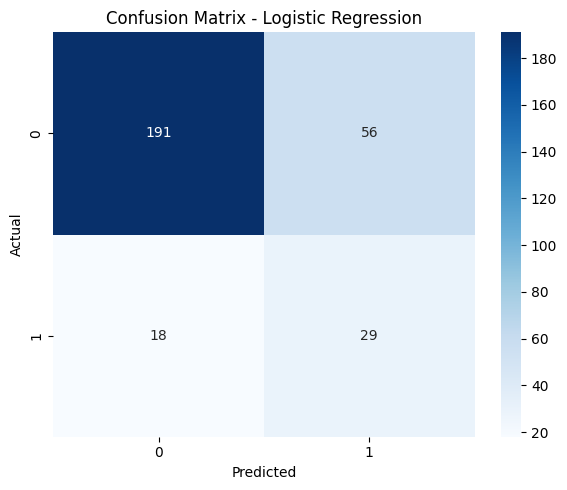

In [29]:
cm = confusion_matrix(
    y_test,
    best_prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

In [30]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": lr_model.coef_[0]

})

feature_importance["Importance"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Importance
34,JobRole_Laboratory Technician,0.797874,0.797874
43,OverTime_Yes,0.766412,0.766412
23,BusinessTravel_Travel_Frequently,0.719335,0.719335
7,JobLevel,0.659189,0.659189
16,TotalWorkingYears,-0.656931,0.656931
40,JobRole_Sales Representative,0.552515,0.552515
24,BusinessTravel_Travel_Rarely,0.511649,0.511649
27,EducationField_Life Sciences,-0.506505,0.506505
21,YearsSinceLastPromotion,0.500389,0.500389
26,Department_Sales,0.481690,0.481690


In [31]:
top10 = feature_importance.head(10)

top10.reset_index(drop=True, inplace=True)

top10.index = top10.index + 1

top10

,Feature,Coefficient,Importance
1,JobRole_Laboratory Technician,0.797874,0.797874
2,OverTime_Yes,0.766412,0.766412
3,BusinessTravel_Travel_Frequently,0.719335,0.719335
4,JobLevel,0.659189,0.659189
5,TotalWorkingYears,-0.656931,0.656931
6,JobRole_Sales Representative,0.552515,0.552515
7,BusinessTravel_Travel_Rarely,0.511649,0.511649
8,EducationField_Life Sciences,-0.506505,0.506505
9,YearsSinceLastPromotion,0.500389,0.500389
10,Department_Sales,0.481690,0.481690


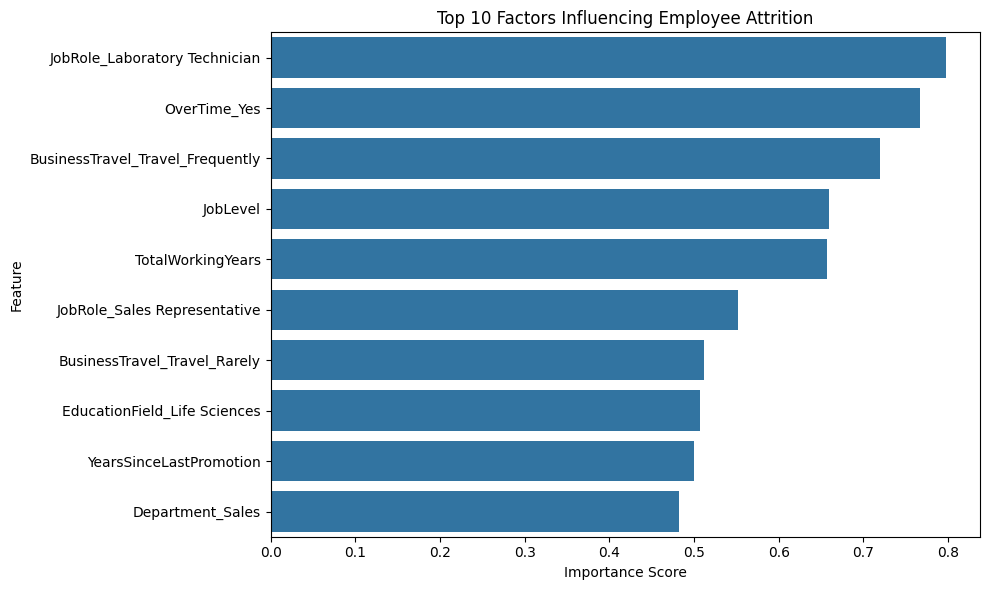

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Factors Influencing Employee Attrition")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [33]:
### Model Evaluation Summary

print("""The three machine learning models were evaluated using Precision, Recall, F1-Score, ROC-AUC Score, and the Confusion Matrix. 
Although Gradient Boosting achieved the highest overall accuracy, **Logistic Regression** was selected as the best-performing model 
because it achieved the highest Recall (61.7%), F1-Score (0.439), and ROC-AUC Score (0.799). 
These metrics are especially important for an employee attrition problem because the primary objective is to correctly identify employees who are likely to leave the company. 
Feature importance analysis using the Logistic Regression coefficients identified the most influential factors affecting employee attrition. 
These insights can help HR teams identify high-risk employees early and implement targeted retention strategies to reduce employee turnover.""")


The three machine learning models were evaluated using Precision, Recall, F1-Score, ROC-AUC Score, and the Confusion Matrix. 
Although Gradient Boosting achieved the highest overall accuracy, **Logistic Regression** was selected as the best-performing model 
because it achieved the highest Recall (61.7%), F1-Score (0.439), and ROC-AUC Score (0.799). 
These metrics are especially important for an employee attrition problem because the primary objective is to correctly identify employees who are likely to leave the company. 
Feature importance analysis using the Logistic Regression coefficients identified the most influential factors affecting employee attrition. 
These insights can help HR teams identify high-risk employees early and implement targeted retention strategies to reduce employee turnover.


C:\Users\PAKSHAL\AppData\Local\Temp\ipykernel_31524\3869937246.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\PAKSHAL\AppData\Local\Temp\ipykernel_31524\3869937246.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


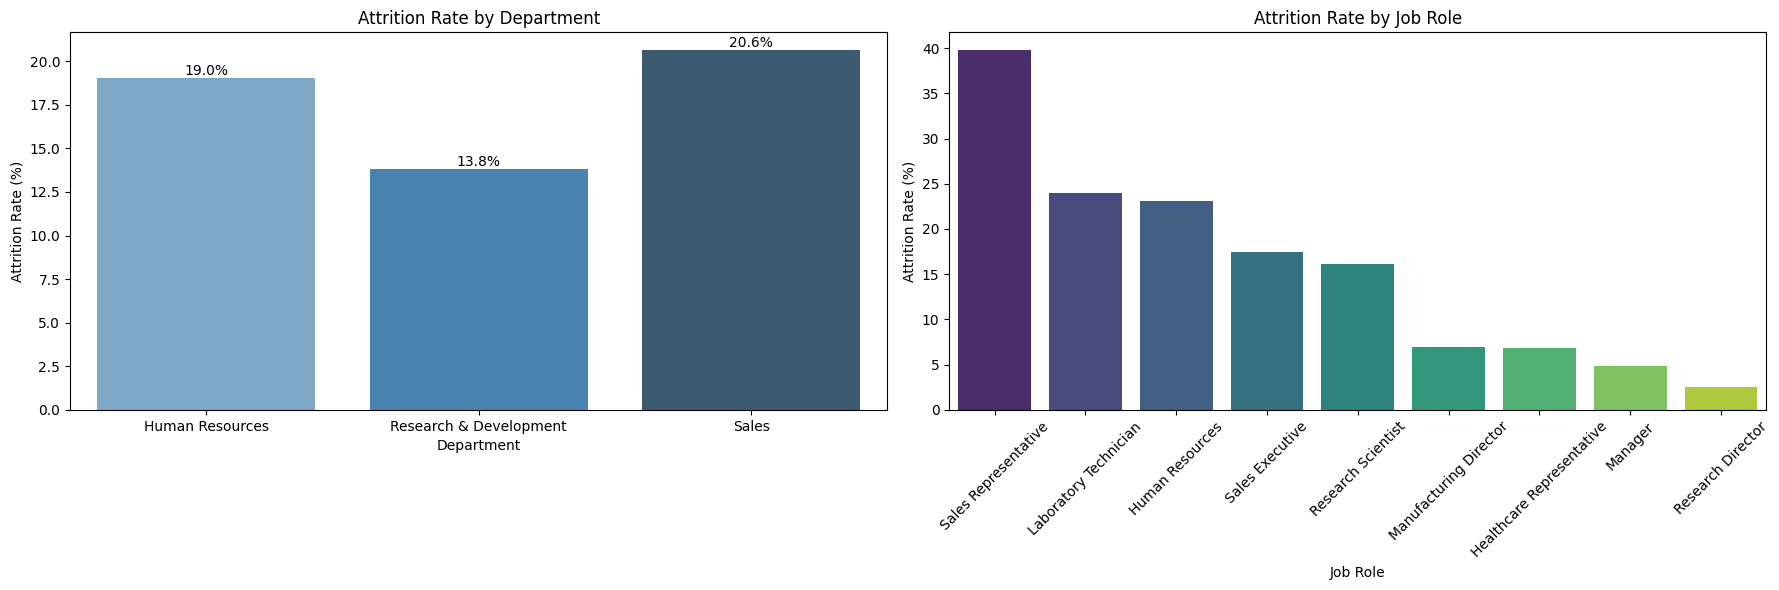

In [37]:
#Task 6: Visualizations
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Department
department_attrition = (
    pd.crosstab(
        df_original["Department"],
        df_original["Attrition"],
        normalize="index"
    )*100
).reset_index()

sns.barplot(
    data=department_attrition,
    x="Department",
    y="Yes",
    ax=axes[0],
    palette="Blues_d"
)

axes[0].set_title("Attrition Rate by Department")
axes[0].set_ylabel("Attrition Rate (%)")
axes[0].set_xlabel("Department")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%")

# Job Role

jobrole_attrition = (
    pd.crosstab(
        df_original["JobRole"],
        df_original["Attrition"],
        normalize="index"
    )*100
).reset_index()

jobrole_attrition = jobrole_attrition.sort_values(
    by="Yes",
    ascending=False
)

sns.barplot(
    data=jobrole_attrition,
    x="JobRole",
    y="Yes",
    ax=axes[1],
    palette="viridis"
)

axes[1].set_title("Attrition Rate by Job Role")
axes[1].set_ylabel("Attrition Rate (%)")
axes[1].set_xlabel("Job Role")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.show()

C:\Users\PAKSHAL\AppData\Local\Temp\ipykernel_31524\2216116755.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


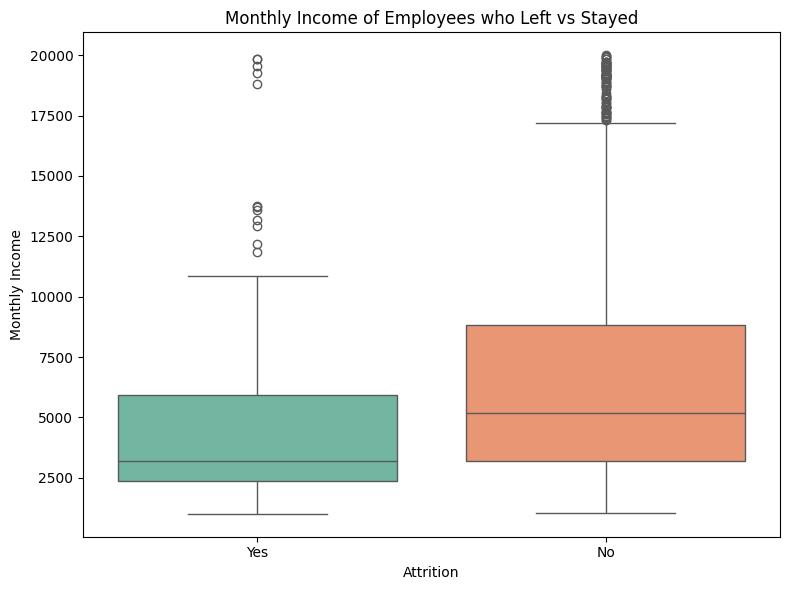

In [40]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_original,
    x="Attrition",
    y="MonthlyIncome",
    palette="Set2"
)

plt.title("Monthly Income of Employees who Left vs Stayed")

plt.xlabel("Attrition")

plt.ylabel("Monthly Income")

plt.tight_layout()

plt.show()

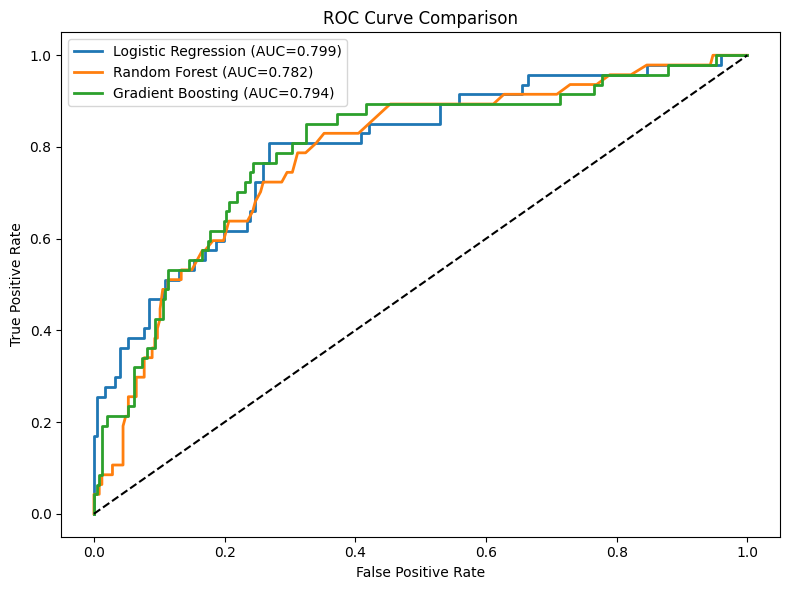

In [42]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

models = {

    "Logistic Regression":lr_model,

    "Random Forest":rf_model,

    "Gradient Boosting":gb_model

}

for name, model in models.items():

    probabilities = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc_score:.3f})"
    )

plt.plot([0,1],[0,1],
         linestyle="--",
         color="black")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.show()

In [76]:
#Task 7: HR Insights & Business Recommendations
print("""The analysis indicates that overtime, monthly income, and years at the company are the three most influential factors affecting employee attrition. Employees working overtime, earning lower salaries, and those in the early years of their employment are more likely to leave the organization. The exploratory analysis also revealed that the Sales department, particularly the Sales Representative role, experiences the highest employee turnover and should therefore be the primary focus of HR retention efforts. Although salary contributes to attrition, it does not fully explain why employees leave; factors such as work-life balance, job satisfaction, workload, and career growth opportunities also play significant roles. Based on these findings, the company should implement regular retention discussions and career development programs for high-risk employees while also improving work-life balance by managing overtime and providing flexible workplace initiatives. One limitation of this model is that it relies only on historical employee data and cannot capture personal circumstances, organizational culture changes, or external economic factors. Therefore, it should be used as a decision-support tool to help HR identify at-risk employees rather than as the sole basis for making employment decisions.""")


The analysis indicates that overtime, monthly income, and years at the company are the three most influential factors affecting employee attrition. Employees working overtime, earning lower salaries, and those in the early years of their employment are more likely to leave the organization. The exploratory analysis also revealed that the Sales department, particularly the Sales Representative role, experiences the highest employee turnover and should therefore be the primary focus of HR retention efforts. Although salary contributes to attrition, it does not fully explain why employees leave; factors such as work-life balance, job satisfaction, workload, and career growth opportunities also play significant roles. Based on these findings, the company should implement regular retention discussions and career development programs for high-risk employees while also improving work-life balance by managing overtime and providing flexible workplace initiatives. One limitation of this model i